In [1]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

from dspl_generator import DSPLGenerator

/opt/anaconda3/envs/herculensenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
gen = DSPLGenerator(15, lens_img='data/euclid_deep_VIS1.npy', source1_img=None, source2_img=None, telescope='euclid', source1_amp=1, source2_amp=1)

In [3]:
lens_image, mass_kwargs, light_kwargs, eta_flat = gen.get_lens_image()

In [4]:
gen.shuffle()
model = gen.get_model()
sim = gen.get_simulation()

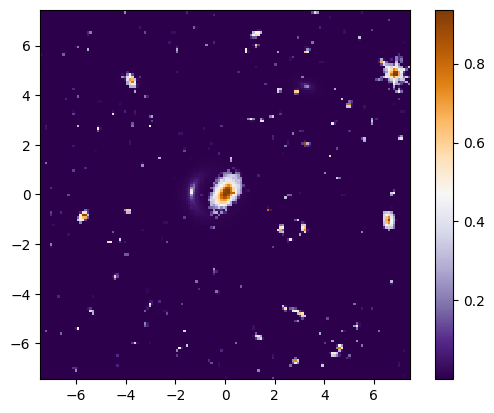

In [5]:
plt.imshow(model, origin='lower', cmap='PuOr_r', extent=gen.pixel_grid.extent)
plt.colorbar()
plt.show()

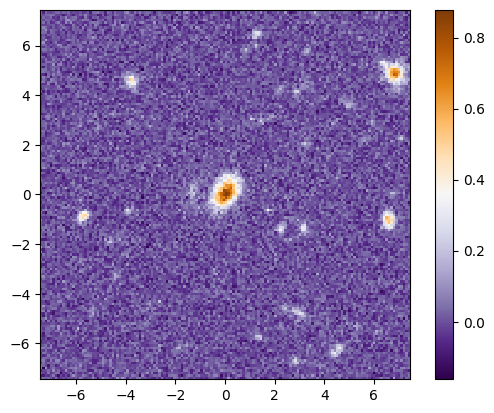

In [6]:
plt.imshow(sim, origin='lower', cmap='PuOr_r', extent=gen.pixel_grid.extent)
plt.colorbar()
plt.show()

In [7]:
gen.shuffle()

In [8]:
mu_lens, mu_s1 = gen.get_magnification()
lens_cc, s1_cc = gen.get_critical_curves()

s1_caustics, s2_caustics = gen.get_caustics()

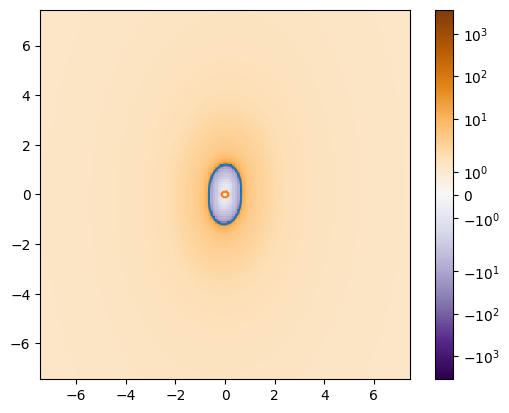

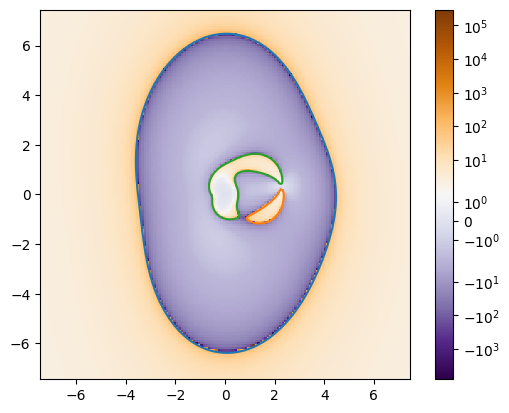

In [9]:
plt.imshow(mu_lens, norm='symlog', cmap='PuOr_r', extent=gen.pixel_grid.extent)
for c in lens_cc:
    plt.plot(c[:, 0], c[:, 1])
plt.colorbar()
plt.show()

plt.imshow(mu_s1, norm='symlog', cmap='PuOr_r', extent=gen.pixel_grid.extent)
for c in s1_cc:
    plt.plot(c[:, 0], c[:, 1])
plt.colorbar()
plt.show()

In [10]:
def get_caustics(curve):
    """
    get the caustics on source1 and source2

    Returns
    -------
    contours_phys_lens : list[points]
        A list of points which give the lens effective critical curves. Each curve is a different nested list.
    contours_phys_s1 : list[points]
        A list of points which give the source1 critical curves. Each curve is a different nested list.
    """
    s1_caustics = []
    s2_caustics = []
    for curve in lens_cc:
        x_img = jnp.array(curve[:, 0])
        y_img = jnp.array(curve[:, 1])
        
        x_deflected, y_deflected = gen.mass_model.ray_shooting(x_img, y_img, eta_flat=gen.eta, kwargs=gen.mass_kwargs)
        x_s1 = x_deflected.T[:, 1]
        y_s1 = y_deflected.T[:, 1]

        x_s2 = x_deflected.T[:, 2]
        y_s2 = y_deflected.T[:, 2]
        
        s1_caustics.append(np.column_stack([np.array(x_s1), np.array(y_s1)]))
        s2_caustics.append(np.column_stack([np.array(x_s2), np.array(y_s2)]))

    return s1_caustics, s2_caustics

In [11]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

from dspl_generator import DSPLGenerator

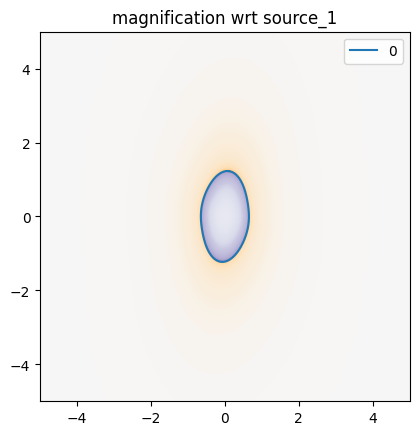

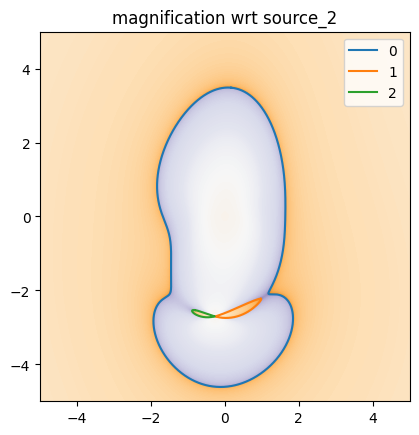

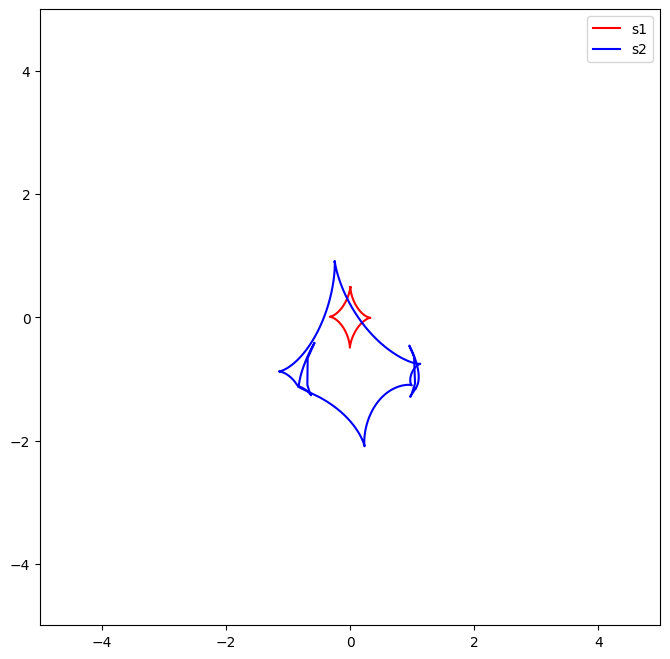

In [12]:
gen = DSPLGenerator(10, lens_img='data/euclid_deep_VIS1.npy', source1_img=None, source2_img='data/euclid_deep_VIS2.npy', telescope='example')


mu_lens, mu_s1 = gen.get_magnification()
lens_cc, s1_cc = gen.get_critical_curves()

plt.imshow(mu_lens, norm='symlog', cmap='PuOr_r', extent=gen.pixel_grid.extent)
for i, c in enumerate(lens_cc):
    plt.plot(c[:, 0], c[:, 1], label=i)
plt.title("magnification wrt source_1")
plt.legend()
plt.show()

plt.imshow(mu_s1, norm='symlog', cmap='PuOr_r', extent=gen.pixel_grid.extent)
for i, c in enumerate(s1_cc):
    plt.plot(c[:, 0], c[:, 1], label=i)
plt.title("magnification wrt source_2")
plt.legend()
plt.show()


s1_caustics, s2_caustics = gen.get_caustics()


plt.figure(figsize=(8,8))

for i, c in enumerate(s1_caustics):
    if i==0:
        plt.plot(c[:,0], c[:,1], c='red', label='s1')
    else:
        plt.plot(c[:,0], c[:,1], c='red')

for i, c in enumerate(s2_caustics):
    if i==0:
        plt.plot(c[:,0], c[:,1], c='blue', label='s2')
    else:
        plt.plot(c[:,0], c[:,1], c='blue')


x_min, x_max, y_min, y_max = gen.pixel_grid.extent

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.legend()
plt.savefig("figures_out/caustics_dspl10.png")
plt.show()


In [13]:
from dspl_generator import DSPLGenerator
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp

In [14]:
gen = DSPLGenerator(15)

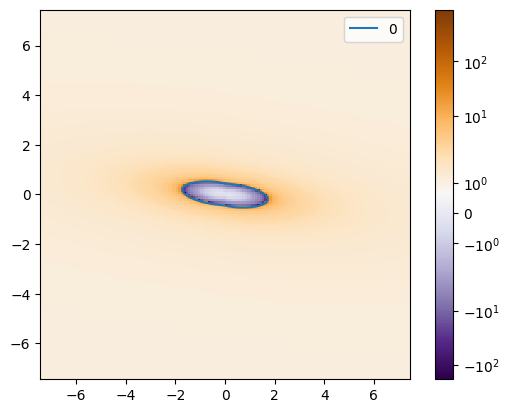

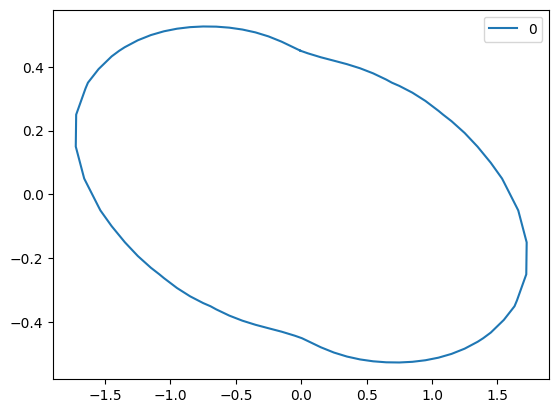

In [15]:
mu_wrts1, mu_wrts2 = gen.get_magnification()
cc_wrts1, cc_wrts2 = gen.get_critical_curves()

plt.imshow(mu_wrts1, extent=gen.pixel_grid.extent, cmap="PuOr_r", norm='symlog')

for i, c in enumerate(cc_wrts1):
    plt.plot(c[:, 0], c[:, 1], label=i)

plt.legend()
plt.colorbar();
plt.show()

for i, c in enumerate(cc_wrts1):
    plt.plot(c[:,0], c[:,1], label=i)
plt.legend()
plt.show()

In [16]:
init_guess = [[-0.7, -1.0], [1e-5,-1e-5]]
paths, _ = gen._critical_curves(init_guess=init_guess, plane=1, N=100_000, delta=1e-4, kind="auto")
print(_)

[[2 2]
 [2 2]]


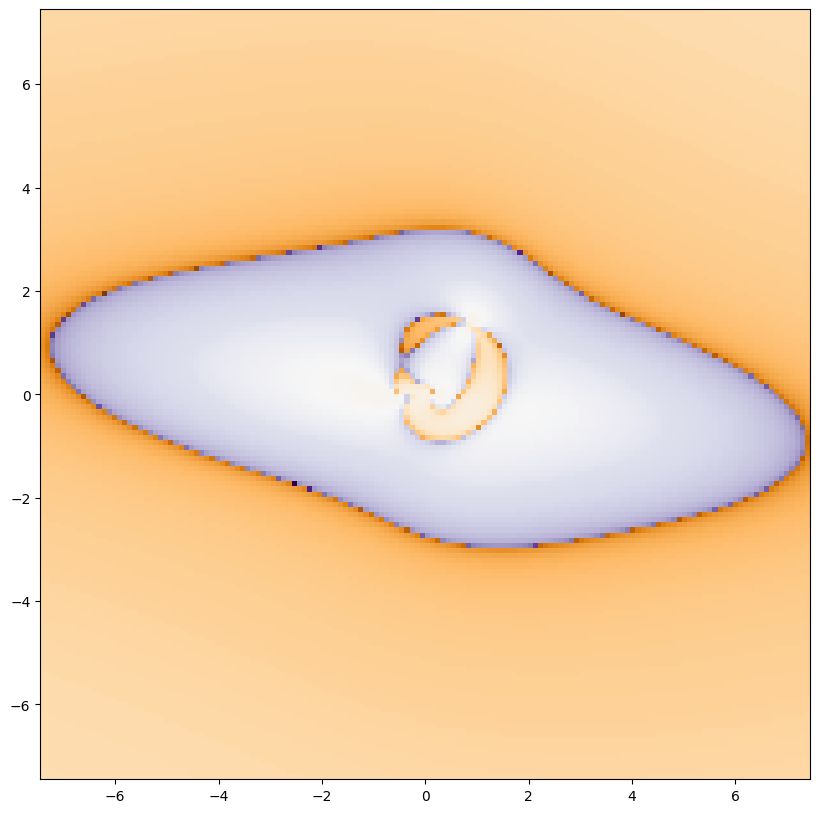

In [17]:
plt.figure(figsize=(10, 10))
plt.imshow(
    mu_wrts2,
    extent=gen.pixel_grid.extent,
    norm="symlog",
    cmap='PuOr_r',
    origin='lower',
    interpolation='nearest'
)

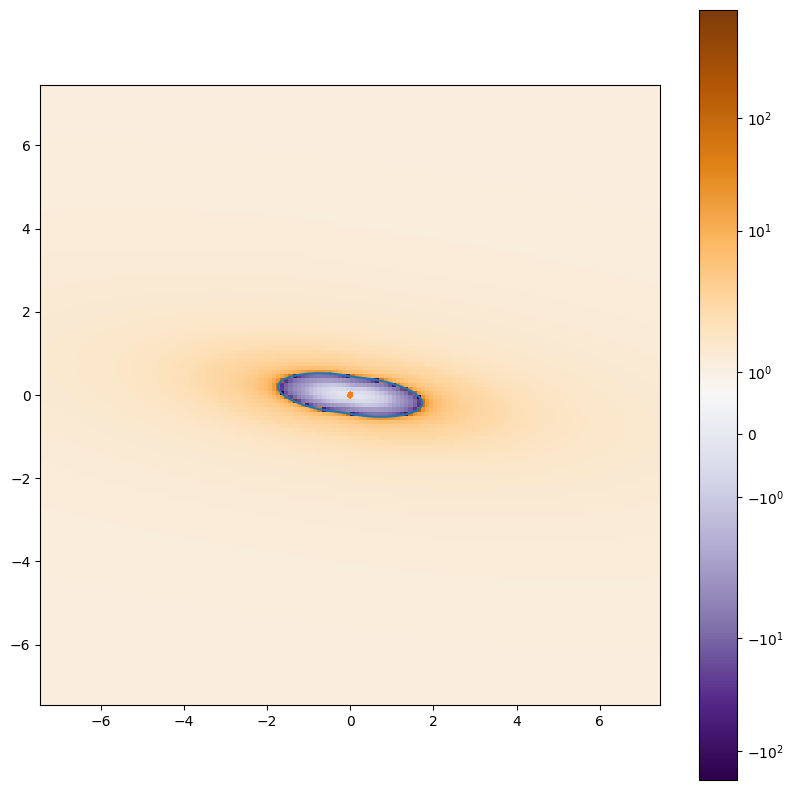

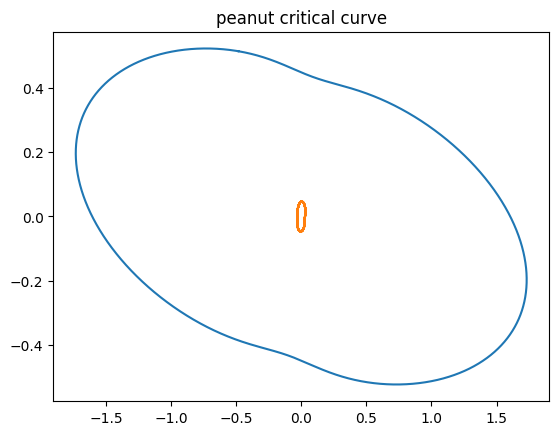

In [18]:
plt.figure(figsize=(10, 10))
plt.imshow(
    mu_wrts1,
    extent=gen.pixel_grid.extent,
    norm="symlog",
    cmap='PuOr_r',
    origin='lower',
    interpolation='nearest'
)

plt.plot(*paths['path'].T)
plt.colorbar()
plt.show()

plt.plot(*paths['path'].T);
plt.title("peanut critical curve")
# plt.savefig("figures_out/peanut_cc.png")
plt.show()

In [19]:
paths_arr = jnp.asarray(paths['path'])

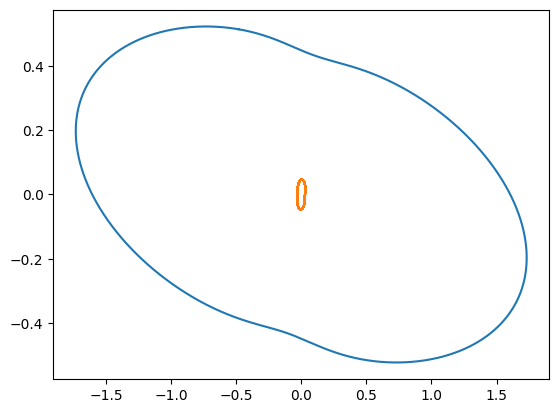

In [20]:
for c in paths_arr:
    plt.plot(c[:, 0], c[:,1])
plt.show()

In [21]:
paths_arr.shape

(2, 200001, 2)

In [22]:
import jax 
import jax.numpy as jnp

def _map(curves, plane):
    """
    curves: shape (n_curves, n_points, 2)
    plane: which mass plane to return
    """
    n_curves, n_points, _ = curves.shape

    x_flat = curves[..., 0].reshape(-1)  
    y_flat = curves[..., 1].reshape(-1)
    L = x_flat.shape[0]

    # vmap over points
    batched_ray_shooting = jax.vmap(
        gen.mass_model.ray_shooting,
        in_axes=(0, 0, None, None)  
    )

    x_def, y_def = batched_ray_shooting(
        x_flat,
        y_flat,
        gen.eta,
        gen.mass_kwargs
    )

    x_def = jnp.asarray(x_def)[:, plane, 0]
    y_def = jnp.asarray(y_def)[:, plane, 0]
    
    # reshape to separate curves
    new_shape = (n_curves, n_points) + x_def.shape[1:]
    x_def = x_def.reshape(new_shape)
    y_def = y_def.reshape(new_shape)

    return x_def, y_def


caust_x, caust_y = _map(curves=paths_arr, plane=2)

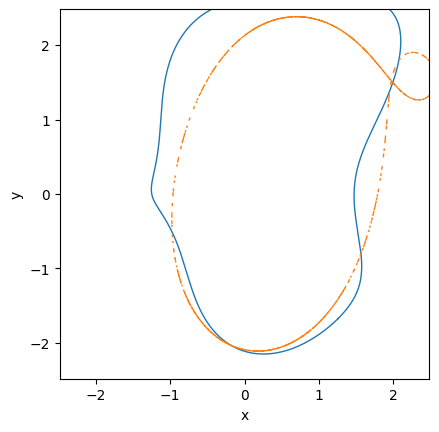

In [23]:

import jax
import numpy as np
import matplotlib.pyplot as plt

# caust is (x_plane, y_plane)
x_plane, y_plane = caust_x, caust_y

# convert to host numpy arrays
x_plane = jax.device_get(x_plane)
y_plane = jax.device_get(y_plane)

# handle both shapes: (n_curves, n_points) or (n_points,)
if x_plane.ndim == 1:
    plt.plot(x_plane, y_plane, '-')
else:
    for i in range(x_plane.shape[0]):
        plt.plot(x_plane[i], y_plane[i], '-', lw=1)

x_min, x_max, y_min, y_max = np.array(gen.pixel_grid.extent)/3
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.gca().set_aspect('equal', 'box')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [24]:
from dspl_generator import DSPLGenerator

In [25]:
gen = DSPLGenerator(15)

In [26]:
gen._inverse_magnification()

TypeError: DSPLGenerator._inverse_magnification() missing 4 required positional arguments: 'x', 'y', 'plane', and 'kind'